# RF-3DGS 数据集生成 (Etoile 场景, 多辐射源)

基于 RF-3DGS 教程的数据格式，使用 Sionna 内置 etoile 场景生成 MPC（多径分量）空间频谱数据集。

**输出格式 (COLMAP 兼容):**
```
dataset/
├── images/          — 频谱图像 (PNG, jet colormap)
├── sparse/
│   └── 0/
│       ├── cameras.txt   — 相机内参 (PINHOLE 模型)
│       ├── images.txt    — 相机外参 (四元数旋转 + 平移)
│       └── points3D.txt  — 初始点云
├── train_index.txt  — 训练集索引
└── test_index.txt   — 测试集索引
```

**特性:**
- 多个全向天线辐射源 (TX)
- 通过 coverage map 确保接收点不在墙内
- MPC/Ideal Spectrum 方式 (无需波束赋形)

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import cv2
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
tf.get_logger().setLevel('ERROR')

import sionna
import sionna.rt
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray,PathSolver
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import imageio

np.random.seed(42)
tf.random.set_seed(42)

W0000 00:00:1772761406.328525   61214 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 1. 参数配置

In [2]:
# ========== 输出目录 ==========
OUTPUT_DIR = './dataset/etoile_demo'

# ========== 场景参数 ==========
SCENE_FREQ = 3.5e9          # 3.5 GHz (5G 中频段)
RX_HEIGHT = 1.5              # 接收器高度 (m)
TX_HEIGHT = 25.0             # 发射器高度 (m), 楼顶基站

# ========== 图像参数 ==========
IMAGE_WIDTH = 300
IMAGE_HEIGHT = 200
FOV = 90                     # 水平视场角 (度)

# ========== 采样参数 ==========
NUM_RX_SAMPLES = 120          # 最终使用的接收点数量
VIEW_ANGLES = [-np.pi/2, 0, np.pi/2, np.pi]  # 每个位置4个朝向

# ========== 射线追踪参数 ==========
MAX_DEPTH = 3                # 最大反射/散射深度
SCAT_KEEP_PROB = 0.3         # 散射保留概率
NUM_RT_SAMPLES = int(1e6)    # 射线数量

# ========== 频谱渲染参数 ==========
IMAGE_SCALE = 3              # 等距圆柱投影分辨率倍数
BOX_HALF_SIZE = 60           # 方块核半径 (像素), 完整核边长 = 2*half+1
DYNAMIC_RANGE_DB = 60.0      # 频谱动态范围 (dB), 低于峰值此值的区域映射为底色

# ========== 全局归一化参数 (dB 域) ==========
# 所有频谱图像共用同一把尺子: [GLOBAL_DB_MIN, GLOBAL_DB_MAX]
# 低于 GLOBAL_DB_MIN 的映射为 jet 底色 (蓝), 高于 GLOBAL_DB_MAX 的映射为 jet 顶色 (红)
# 可先跑一次打印各 RX 的 peak dB, 再据此调整
GLOBAL_DB_MIN = -130.0       # 全局信号下限 (dB)
GLOBAL_DB_MAX = -70.0        # 全局信号上限 (dB)

# ========== Coverage Map 参数 ==========
CM_CELL_SIZE = 5.0           # 覆盖图网格大小 (m)
CM_NUM_SAMPLES = int(2e6)    # 覆盖图射线数量

# ========== Train/Test 分割 ==========
TRAIN_RATIO = 0.8            # 训练集比例

## 2. 加载场景 & 配置天线

In [3]:
scene = load_scene(sionna.rt.scene.etoile)
scene.frequency = SCENE_FREQ

# TX: 单个全向天线 (每个辐射源)
scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V",
)

# RX: 单个全向天线 (MPC spectrum 不需要阵列)
scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V",
)

## 3. 添加多个辐射源 (TX)

在场景中不同位置放置全向天线辐射源，模拟多基站场景。
TX 放置在建筑物高度，确保具有良好的覆盖。

In [4]:
# 清除已有设备
for name in list(scene.transmitters.keys()):
    scene.remove(name)
for name in list(scene.receivers.keys()):
    scene.remove(name)

# 定义多个辐射源位置 (x, y, z)
# etoile 场景以凯旋门为中心，多条大道向外辐射
# TX 放在不同方位的高处
tx_positions = [
    [60,   40,  TX_HEIGHT],    # 东北区域
    [-50, -70,  TX_HEIGHT],    # 西南区域
    [80,  -30,  TX_HEIGHT],    # 东南区域
]

for i, pos in enumerate(tx_positions):
    # sionna expects a sequence of floats for position (not a numpy ndarray)
    tx = Transmitter(name=f"tx_{i}", position=pos)
    scene.add(tx)
    print(f"  TX_{i}: position = {pos}")

num_tx = len(tx_positions)
print(f"\n共添加 {num_tx} 个辐射源")

  TX_0: position = [60, 40, 25.0]
  TX_1: position = [-50, -70, 25.0]
  TX_2: position = [80, -30, 25.0]

共添加 3 个辐射源


# 4. 添加RX并用LoS验证位置有效性

In [5]:
print("正在通过 LoS/反射 验证生成有效接收位置...")

# 在场景范围内生成候选网格
# etoile 场景大约 ±200m, 街道集中在 ±120m 范围内
GRID_SPACING = 10  # 每 15m 一个候选点
grid_x = np.arange(-120, 121, GRID_SPACING)
grid_y = np.arange(-120, 121, GRID_SPACING)

candidates = []
for x in grid_x:
    for y in grid_y:
        # 添加小随机偏移避免所有点落在同一网格线上
        x_offset = np.random.uniform(-GRID_SPACING * 0.3, GRID_SPACING * 0.3)
        y_offset = np.random.uniform(-GRID_SPACING * 0.3, GRID_SPACING * 0.3)
        candidates.append([float(x + x_offset), float(y + y_offset), RX_HEIGHT])

print(f"候选点: {len(candidates)} 个")

# PathSolver 只创建一次 (避免循环内重复创建)
p_solver = PathSolver()

# 验证: 对每个候选位置计算路径, 有信号说明在室外
valid_rx_locs = []
for i, pos in enumerate(candidates):
    if i % 50 == 0:
        print(f"  验证进度: {i}/{len(candidates)}")
    try:
        scene.remove("rx_validate")
    except Exception:
        pass

    rx = Receiver(name="rx_validate", position=pos)
    scene.add(rx)

    try:
        paths = p_solver(
            scene=scene,
            max_depth=1,
            refraction=True,
            diffraction=False,
            diffuse_reflection=False,
            samples_per_src=int(1e5)
        )
        # 检查是否有任何有效路径
        total_gain = float(np.sum(np.abs(paths.a)))
        if total_gain > 0:
            valid_rx_locs.append(pos)
    except Exception:
        pass  # 跳过计算失败的位置

scene.remove("rx_validate")

print(f"\nLoS 验证通过: {len(valid_rx_locs)} / {len(candidates)} 个有效位置")

# 从有效位置中随机采样
if len(valid_rx_locs) > NUM_RX_SAMPLES:
    indices = np.random.choice(len(valid_rx_locs), NUM_RX_SAMPLES, replace=False)
    rx_locs = [valid_rx_locs[i] for i in indices]
else:
    rx_locs = valid_rx_locs

print(f"最终采样: {len(rx_locs)} 个接收点")

for i, pos in enumerate(rx_locs):
    rx = Receiver(name=f"rx_final_{i}", position=pos)
    scene.add(rx)

正在通过 LoS/反射 验证生成有效接收位置...
候选点: 625 个
  验证进度: 0/625
  验证进度: 50/625
  验证进度: 100/625
  验证进度: 150/625
  验证进度: 200/625
  验证进度: 250/625
  验证进度: 300/625
  验证进度: 350/625
  验证进度: 400/625
  验证进度: 450/625
  验证进度: 500/625
  验证进度: 550/625
  验证进度: 600/625

LoS 验证通过: 550 / 625 个有效位置
最终采样: 120 个接收点


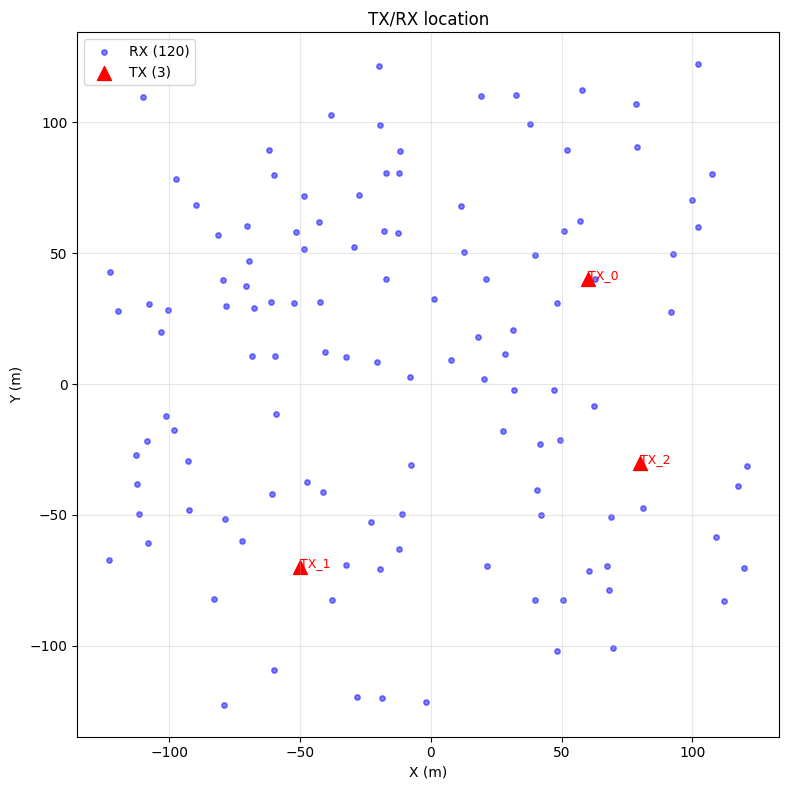

数据集大小: 120 个位置 × 4 个朝向 = 480 张频谱图


In [6]:
# 可视化 TX 和 RX 位置
rx_locs_arr = np.array(rx_locs)
tx_locs_arr = np.array(tx_positions)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

ax.scatter(rx_locs_arr[:, 0], rx_locs_arr[:, 1],
           c='blue', marker='o', s=15, alpha=0.5, label=f'RX ({len(rx_locs)})')
ax.scatter(tx_locs_arr[:, 0], tx_locs_arr[:, 1],
           c='red', marker='^', s=100, label=f'TX ({num_tx})')

for i, pos in enumerate(tx_positions):
    ax.annotate(f'TX_{i}', (pos[0], pos[1]), fontsize=9, color='red')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('TX/RX location')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"数据集大小: {len(rx_locs)} 个位置 × {len(VIEW_ANGLES)} 个朝向 = {len(rx_locs)*len(VIEW_ANGLES)} 张频谱图")


In [7]:
# Monkey-patch: Sionna 传小写 'xyz' 但新版 pythreejs 要求大写 'XYZ'
import pythreejs
_orig_euler_init = pythreejs.Euler.__init__
def _patched_euler_init(self, *args, **kwargs):
    if args and isinstance(args[0], str):
        args = (args[0].upper(), *args[1:])
    if 'order' in kwargs and isinstance(kwargs['order'], str):
        kwargs['order'] = kwargs['order'].upper()
    _orig_euler_init(self, *args, **kwargs)
pythreejs.Euler.__init__ = _patched_euler_init

scene.preview()

## 5. 工具函数

包含 COLMAP 格式 I/O、频谱渲染、坐标变换等工具。

In [8]:
# ==================== COLMAP 格式相关 ====================

class ColmapCamera:
    """COLMAP 相机内参"""
    def __init__(self, id, model, width, height, params):
        self.id = id
        self.model = model
        self.width = width
        self.height = height
        self.params = params   # [fx, fy, cx, cy]

class ColmapImage:
    """COLMAP 图像外参 (world-to-camera)"""
    def __init__(self, id, qvec, tvec, camera_id, name):
        self.id = id
        self.qvec = qvec      # [qw, qx, qy, qz] world-to-camera rotation
        self.tvec = tvec       # world-to-camera translation
        self.camera_id = camera_id
        self.name = name

def save_cameras_txt(path, cameras):
    """保存 cameras.txt (COLMAP 格式)"""
    with open(path, "w") as f:
        f.write("# Camera list with one line of data per camera:\n")
        f.write("# CAMERA_ID, MODEL, WIDTH, HEIGHT, PARAMS[fx,fy,cx,cy]\n")
        for cam_id, cam in cameras.items():
            params_str = " ".join(map(str, cam.params))
            f.write(f"{cam_id} {cam.model} {cam.width} {cam.height} {params_str}\n")

def save_images_txt(path, images):
    """保存 images.txt (COLMAP 格式, w2c 四元数 + w2c 平移)"""
    with open(path, "w") as f:
        f.write("# Image list with two lines of data per image:\n")
        f.write("# IMAGE_ID, QW, QX, QY, QZ, TX, TY, TZ, CAMERA_ID, NAME\n")
        f.write("# POINTS2D[] as (X, Y, POINT3D_ID)\n")
        for img_id, img in images.items():
            qvec_str = " ".join(map(str, img.qvec))
            tvec_str = " ".join(map(str, img.tvec))
            f.write(f"{img_id} {qvec_str} {tvec_str} {img.camera_id} {img.name}\n")
            f.write("\n")  # POINTS2D 空行

def save_points3D_txt(path, num_points=100000, bounds_min=(-120, -120, 0), bounds_max=(120, 120, 40)):
    """
    生成随机的初始点云 (Fake Point Cloud)，专供 3DGS 初始化高斯球使用。

    etoile 场景的范围大约是 XY 在 ±120m 内，高度 Z 在 0 到 40m (建筑物高度) 左右。
    """
    import numpy as np

    print(f"正在生成 {num_points} 个随机初始 3D 高斯点供训练使用...")
    with open(path, "w") as f:
        f.write("# 3D point list with one line of data per point:\n")
        f.write("# POINT3D_ID, X, Y, Z, R, G, B, ERROR, TRACK[] as (IMAGE_ID, POINT2D_IDX)\n")

        # 在场景 Bounding Box 内均匀撒点
        pts_x = np.random.uniform(bounds_min[0], bounds_max[0], num_points)
        pts_y = np.random.uniform(bounds_min[1], bounds_max[1], num_points)
        pts_z = np.random.uniform(bounds_min[2], bounds_max[2], num_points)

        # 初始颜色：可以给随机颜色，也可以统一给灰色。
        # 给随机颜色能让 3DGS 初期梯度更活跃，快速区分出不同区域的特征
        colors = np.random.randint(0, 255, (num_points, 3))

        # 写入点云
        for i in range(num_points):
            point_id = i + 1
            x, y, z = pts_x[i], pts_y[i], pts_z[i]
            r, g, b = colors[i]
            error = 0.0  # 我们没有重投影误差，直接给 0

            # 格式要求：ID, X, Y, Z, R, G, B, ERROR。
            # 最后的 TRACK (哪些图片看到了这个点) 在 3DGS 初始化时其实是不看的，留空即可！
            f.write(f"{point_id} {x:.4f} {y:.4f} {z:.4f} {r} {g} {b} {error}\n")

def calculate_camera_intrinsics(width, height, focal_length):
    """计算 PINHOLE 相机内参"""
    fx = fy = focal_length
    cx = width / 2.0
    cy = height / 2.0
    return fx, fy, cx, cy

# ==================== 坐标变换 ====================

def euler_to_quaternion(euler_angles):
    """
    将 Sionna 的欧拉角 (yaw, pitch, roll) 转换为 COLMAP 格式的
    world-to-camera (w2c) 四元数和旋转矩阵。
    """
    R_posz2posx = Rotation.from_euler('ZYX', [-np.pi/2, 0.0, -np.pi/2])
    yaw, pitch, roll = euler_angles
    R_posx2array = Rotation.from_euler('ZYX', [yaw, pitch, roll])
    R_w2c = R_posx2array * R_posz2posx
    q = R_w2c.as_quat()  # scipy 返回 [qx, qy, qz, qw]
    qvec_w2c = [q[3], q[0], q[1], q[2]]
    return R_w2c, qvec_w2c

# ==================== 频谱渲染 ====================

def plot_multi_tx_spectrum(paths, num_tx, image_scale=3, box_half_size=60,
                           dynamic_range_db=25.0):
    """
    渲染多 TX 合并的 MPC 空间频谱 (等距圆柱投影)。

    每个多径分量按其 AoA (theta_r, phi_r) 和振幅绘制为方块点，
    所有 TX 的贡献叠加到同一张图上。

    使用 Box Kernel (方块核): 每个 MPC 在其到达角位置放置一个
    (2*box_half_size+1) x (2*box_half_size+1) 的均匀方块,
    产生硬边、精准的像素方块, 无高斯模糊光晕。

    Sionna v1.0 PathSolver API:
      - paths.a -> tuple (a_real, a_imag), 各 shape [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
      - paths.theta_r -> shape [num_rx, num_tx, num_paths]
      - paths.phi_r   -> shape [num_rx, num_tx, num_paths]

    Args:
        box_half_size: 方块核半径 (像素)。完整核边长 = 2*half+1。
        dynamic_range_db: 动态范围 (dB)。背景 floor = peak - dynamic_range_db。

    返回: [360*scale, 180*scale] 的 dB 域频谱 (已做动态范围裁剪)
    """
    # 解包 paths.a (Sionna v1: 返回 tuple (a_real, a_imag))
    a_real, a_imag = paths.a
    a_real_np = np.array(a_real)
    a_imag_np = np.array(a_imag)

    # 角度: shape [num_rx, num_tx, num_paths]
    theta_r_np = np.array(paths.theta_r)
    phi_r_np = np.array(paths.phi_r)

    img_h = 360 * image_scale
    img_w = 180 * image_scale
    img = np.zeros((img_h, img_w))

    # 方块核: 均匀权重, 边长 = 2*box_half_size+1
    half = box_half_size
    box_side = 2 * half + 1
    box_kernel = np.ones((box_side, box_side))

    for tx_idx in range(num_tx):
        # theta_r / phi_r: [num_rx, num_tx, num_paths], 取 rx_idx=0
        theta = theta_r_np[0, tx_idx, :] * 180 / np.pi
        phi = phi_r_np[0, tx_idx, :] * 180 / np.pi
        # a: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths], 取 rx=0, rx_ant=0, tx_ant=0
        amps = np.sqrt(a_real_np[0, 0, tx_idx, 0, :]**2 + a_imag_np[0, 0, tx_idx, 0, :]**2)

        for idx, intensity in enumerate(amps):
            if intensity > 0:
                # 均匀分配: 每个像素获得 intensity / 核面积
                path_dot = box_kernel * intensity / np.sum(box_kernel)

                phi_idx = int(-phi[idx] + 180) * image_scale
                theta_idx = int(theta[idx]) * image_scale

                xmin = max(0, phi_idx - half)
                xmax = min(img_h, phi_idx + half + 1)
                ymin = max(0, theta_idx - half)
                ymax = min(img_w, theta_idx + half + 1)

                kern_xmin = max(0, half - phi_idx)
                kern_xmax = min(box_side, img_h - phi_idx + half)
                kern_ymin = max(0, half - theta_idx)
                kern_ymax = min(box_side, img_w - theta_idx + half)

                img[xmin:xmax, ymin:ymax] += path_dot[kern_xmin:kern_xmax, kern_ymin:kern_ymax]

    # 转换到 dB 域，使用动态范围裁剪
    non_zero_mask = img != 0.0
    if np.any(non_zero_mask):
        img[non_zero_mask] = 10 * np.log10(img[non_zero_mask])
        peak_db = np.max(img[non_zero_mask])
        floor_db = peak_db - dynamic_range_db
        # 将零值区域和低于 floor 的区域全部设为 floor
        img[~non_zero_mask] = floor_db
        img = np.maximum(img, floor_db)
    else:
        img[:] = -100  # 无信号

    return img

def jet_colormap_convert(array_2d):
    """将 2D 数组归一化并应用 jet colormap -> [H, W, 3] RGB float (0~1)"""
    arr_min, arr_max = np.min(array_2d), np.max(array_2d)
    if arr_max - arr_min < 1e-12:
        normalized = np.zeros_like(array_2d)
    else:
        normalized = (array_2d - arr_min) / (arr_max - arr_min)
    jet = plt.get_cmap('jet')
    colored = jet(normalized)[:, :, :3]  # 去掉 alpha
    return colored

# ==================== 等距圆柱 → 透视投影 ====================

def xyz2lonlat(xyz):
    norm = np.linalg.norm(xyz, axis=-1, keepdims=True)
    xyz_norm = xyz / norm
    lon = np.arctan2(xyz_norm[..., 0:1], xyz_norm[..., 2:])
    lat = np.arcsin(xyz_norm[..., 1:2])
    return np.concatenate([lon, lat], axis=-1)

def lonlat2XY(lonlat, shape):
    X = (lonlat[..., 0:1] / (2 * np.pi) + 0.5) * (shape[1] - 1)
    Y = (lonlat[..., 1:] / (np.pi) + 0.5) * (shape[0] - 1)
    return np.concatenate([X, Y], axis=-1)

def equirectangular_to_perspective(img, fov, theta_deg, phi_deg, height, width):
    """
    将等距圆柱投影图像转换为透视投影 (PINHOLE 相机)。
    """
    if len(img.shape) == 2:
        img = img[..., np.newaxis]

    f = 0.5 * width / np.tan(0.5 * fov / 180.0 * np.pi)
    cx = (width - 1) / 2.0
    cy = (height - 1) / 2.0
    K = np.array([[f, 0, cx], [0, f, cy], [0, 0, 1]], np.float32)
    K_inv = np.linalg.inv(K)

    x = np.arange(width)
    y = np.arange(height)
    x, y = np.meshgrid(x, y)
    z = np.ones_like(x)
    xyz = np.concatenate([x[..., None], y[..., None], z[..., None]], axis=-1)
    xyz = xyz @ K_inv.T

    y_axis = np.array([0.0, 1.0, 0.0], np.float32)
    x_axis = np.array([1.0, 0.0, 0.0], np.float32)
    R1, _ = cv2.Rodrigues(y_axis * np.radians(theta_deg))
    R2, _ = cv2.Rodrigues(np.dot(R1, x_axis) * np.radians(phi_deg))
    R = R2 @ R1
    xyz = xyz @ R.T
    lonlat = xyz2lonlat(xyz)
    XY = lonlat2XY(lonlat, shape=img.shape).astype(np.float32)

    persp = cv2.remap(img.astype(np.float32), XY[..., 0], XY[..., 1],
                      cv2.INTER_CUBIC, borderMode=cv2.BORDER_WRAP)
    return persp

print("工具函数加载完成")

工具函数加载完成


## 6. 数据集生成

对每个接收位置:
1. 计算来自所有 TX 的多径传播
2. 渲染等距圆柱 MPC 频谱 (合并所有 TX 贡献)
3. 对每个观测朝向，转换为透视投影图像
4. 保存频谱图像 + COLMAP 格式的位姿 + train/test 索引

In [9]:
def generate_dataset(rx_locs, tx_positions, scene, output_dir,
                     image_width, image_height, fov, view_angles,
                     max_depth, scat_keep_prob, num_rt_samples,
                     image_scale, box_half_size,
                     dynamic_range_db=25.0,
                     global_db_min=-100.0, global_db_max=-40.0,
                     train_ratio=0.8):
    """
    生成 RF-3DGS 兼容数据集。

    使用全局归一化: 所有频谱图像共用 [global_db_min, global_db_max] 的 dB 范围，
    映射到 jet colormap 的 [0, 1]。保证不同位置之间的信号强度可直接对比。

    关键改进: 先对单通道归一化频谱做透视投影插值, 再涂 jet 伪彩色,
    避免在 RGB 空间插值导致颜色失真 (如红+蓝 → 非物理中间色)。

    目录结构:
        output_dir/
            images/              — 频谱图像 (PNG)
            sparse/0/            — COLMAP 稀疏重建
                cameras.txt
                images.txt
                points3D.txt
            train_index.txt      — 训练集图像索引
            test_index.txt       — 测试集图像索引
            tx_positions.txt     — 辐射源位置
            rx_positions.txt     — 接收点位置
    """
    images_dir = os.path.join(output_dir, 'images')
    sparse_dir = os.path.join(output_dir, 'sparse', '0')
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(sparse_dir, exist_ok=True)

    num_tx = len(tx_positions)
    cameras = {}
    images = {}

    # ----- 清除场景中所有已有的 RX (避免 PathSolver 计算多余接收器) -----
    for name in list(scene.receivers.keys()):
        scene.remove(name)

    # ----- 相机内参 (所有图像共享) -----
    focal_length = image_width / (2 * np.tan(np.deg2rad(fov) / 2))
    fx, fy, cx, cy = calculate_camera_intrinsics(image_width, image_height, focal_length)
    camera_id = 1
    cameras[camera_id] = ColmapCamera(camera_id, "PINHOLE", image_width, image_height,
                                       [float(fx), float(fy), cx, cy])

    # ----- PathSolver 实例 (复用, 避免重复创建) -----
    p_solver = PathSolver()

    # ----- 遍历每个 RX 位置 -----
    image_counter = 1
    jet_colormap = plt.get_cmap('jet')

    print(f"全局归一化范围: [{global_db_min:.1f}, {global_db_max:.1f}] dB")

    for i, rx_loc in enumerate(rx_locs):
        if i % 20 == 0:
            print(f">>> 生成进度: {i}/{len(rx_locs)}")

        # 计算等距圆柱频谱 (一次计算, 所有 TX 合并)
        try:
            scene.remove("rx_gen")
        except:
            pass
        rx = Receiver(name="rx_gen", position=rx_loc)
        scene.add(rx)

        paths = p_solver(
            scene=scene,
            max_depth=max_depth,
            samples_per_src=num_rt_samples,
            diffuse_reflection=True,
            refraction=True,
            diffraction=False,
        )

        spec_equirect = plot_multi_tx_spectrum(
            paths, num_tx, image_scale, box_half_size,
            dynamic_range_db=dynamic_range_db
        ).T  # [180*scale, 360*scale]

        # 全局归一化: 将 dB 值裁剪到 [global_db_min, global_db_max], 然后线性映射到 [0, 1]
        spec_clamped = np.clip(spec_equirect, global_db_min, global_db_max)
        spec_normalized = (spec_clamped - global_db_min) / (global_db_max - global_db_min)

        # 打印前几个 RX 的 peak 值, 方便用户校准全局范围
        if i < 5:
            peak_val = np.max(spec_equirect)
            floor_val = np.min(spec_equirect)
            print(f"  RX {i}: dB range [{floor_val:.1f}, {peak_val:.1f}]")

        # 对每个观测朝向生成透视图
        for angle in view_angles:
            orientation = [float(angle), 0.0, 0.0]  # yaw, pitch, roll

            # 计算 COLMAP 位姿 (world-to-camera)
            R_w2c, qvec_w2c = euler_to_quaternion(orientation)
            tvec_w2c = -R_w2c.apply(np.array(rx_loc))

            # 先对单通道归一化频谱做等距圆柱 → 透视投影插值
            # 在标量空间插值保证物理意义正确, 避免 RGB 空间插值产生伪色
            perspective_scalar = equirectangular_to_perspective(
                spec_normalized, fov, float(angle * 180 / np.pi), 90,
                image_height, image_width
            )
            perspective_scalar = np.clip(perspective_scalar, 0, 1)

            # 确保是 2D 单通道
            if perspective_scalar.ndim == 3:
                perspective_scalar = perspective_scalar[:, :, 0]

            # 投影后再涂 jet 伪彩色
            perspective_img = jet_colormap(perspective_scalar)[:, :, :3]

            # 保存频谱图像到 images/ 目录
            image_name = f'{image_counter:05d}.png'
            image_path = os.path.join(images_dir, image_name)
            imageio.imwrite(image_path, (perspective_img * 255).astype(np.uint8))

            # 记录 COLMAP 外参 (w2c)
            images[image_counter] = ColmapImage(
                image_counter, qvec_w2c, tvec_w2c.tolist(),
                camera_id, image_name
            )

            image_counter += 1

    try:
        scene.remove("rx_gen")
    except:
        pass

    # ----- 保存 COLMAP 文件到 sparse/0/ -----
    save_cameras_txt(os.path.join(sparse_dir, 'cameras.txt'), cameras)
    save_images_txt(os.path.join(sparse_dir, 'images.txt'), images)
    save_points3D_txt(os.path.join(sparse_dir, 'points3D.txt'))

    # ----- 生成 train/test 索引 -----
    total_images = image_counter - 1
    all_indices = list(range(1, total_images + 1))
    np.random.shuffle(all_indices)
    n_train = int(len(all_indices) * train_ratio)
    train_indices = sorted(all_indices[:n_train])
    test_indices = sorted(all_indices[n_train:])

    with open(os.path.join(output_dir, 'train_index.txt'), 'w') as f:
        for idx in train_indices:
            f.write(f"{idx}\n")

    with open(os.path.join(output_dir, 'test_index.txt'), 'w') as f:
        for idx in test_indices:
            f.write(f"{idx}\n")

    # ----- 保存辅助元数据 -----
    np.savetxt(os.path.join(output_dir, 'tx_positions.txt'), np.array(tx_positions),
               header='x y z', comments='')
    np.savetxt(os.path.join(output_dir, 'rx_positions.txt'), np.array(rx_locs),
               fmt='%.4f', header='x y z', comments='')

    print(f"\n{'='*50}")
    print(f"数据集生成完成!")
    print(f"  输出目录: {output_dir}")
    print(f"  频谱图像: {total_images} 张 ({image_width}x{image_height})")
    print(f"  训练集:   {len(train_indices)} 张")
    print(f"  测试集:   {len(test_indices)} 张")
    print(f"  接收位置: {len(rx_locs)} 个")
    print(f"  辐射源:   {num_tx} 个")
    print(f"  全局 dB 范围: [{global_db_min:.1f}, {global_db_max:.1f}]")
    print(f"{'='*50}")

    return total_images

In [10]:
# 运行数据集生成
total = generate_dataset(
    rx_locs=rx_locs,
    tx_positions=tx_positions,
    scene=scene,
    output_dir=OUTPUT_DIR,
    image_width=IMAGE_WIDTH,
    image_height=IMAGE_HEIGHT,
    fov=FOV,
    view_angles=VIEW_ANGLES,
    max_depth=MAX_DEPTH,
    scat_keep_prob=SCAT_KEEP_PROB,
    num_rt_samples=NUM_RT_SAMPLES,
    image_scale=IMAGE_SCALE,
    box_half_size=BOX_HALF_SIZE,
    dynamic_range_db=DYNAMIC_RANGE_DB,
    global_db_min=GLOBAL_DB_MIN,
    global_db_max=GLOBAL_DB_MAX,
    train_ratio=TRAIN_RATIO,
)

全局归一化范围: [-130.0, -70.0] dB
>>> 生成进度: 0/120
  RX 0: dB range [-140.9, -80.9]
  RX 1: dB range [-138.6, -78.6]
  RX 2: dB range [-140.0, -80.0]
  RX 3: dB range [-140.2, -80.2]
  RX 4: dB range [-144.1, -84.1]
>>> 生成进度: 20/120
>>> 生成进度: 40/120
>>> 生成进度: 60/120
>>> 生成进度: 80/120
>>> 生成进度: 100/120
正在生成 100000 个随机初始 3D 高斯点供训练使用...

数据集生成完成!
  输出目录: ./dataset/etoile_demo
  频谱图像: 480 张 (300x200)
  训练集:   384 张
  测试集:   96 张
  接收位置: 120 个
  辐射源:   3 个
  全局 dB 范围: [-130.0, -70.0]


## 7. 验证输出

检查生成的数据集格式是否正确。

In [11]:
# 检查目录结构
print("=== 目录结构 ===")
for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = '  ' * (level + 1)
    for f in sorted(files)[:5]:
        filepath = os.path.join(root, f)
        size = os.path.getsize(filepath)
        print(f"{sub_indent}{f}  ({size} bytes)")
    if len(files) > 5:
        print(f"{sub_indent}... ({len(files)} files total)")

=== 目录结构 ===
etoile_demo/
  rx_positions.txt  (2912 bytes)
  test_index.txt  (355 bytes)
  train_index.txt  (1457 bytes)
  tx_positions.txt  (234 bytes)
  images/
    00001.png  (636 bytes)
    00002.png  (636 bytes)
    00003.png  (636 bytes)
    00004.png  (636 bytes)
    00005.png  (636 bytes)
    ... (480 files total)
  sparse/
    0/
      cameras.txt  (171 bytes)
      images.txt  (64947 bytes)
      points3D.txt  (4550939 bytes)


In [12]:
# 预览 cameras.txt
print("=== cameras.txt ===")
with open(os.path.join(OUTPUT_DIR, 'sparse', '0', 'cameras.txt'), 'r') as f:
    print(f.read())

=== cameras.txt ===
# Camera list with one line of data per camera:
# CAMERA_ID, MODEL, WIDTH, HEIGHT, PARAMS[fx,fy,cx,cy]
1 PINHOLE 300 200 150.00000000000003 150.00000000000003 150.0 100.0



In [13]:
# 预览 images.txt (前 10 行)
print("=== images.txt (前 10 行) ===")
with open(os.path.join(OUTPUT_DIR, 'sparse', '0', 'images.txt'), 'r') as f:
    for i, line in enumerate(f):
        if i >= 10:
            print("...")
            break
        print(line, end='')

# 预览 train/test 索引
print("\n\n=== train_index.txt (前 10 行) ===")
with open(os.path.join(OUTPUT_DIR, 'train_index.txt'), 'r') as f:
    for i, line in enumerate(f):
        if i >= 10:
            print("...")
            break
        print(line, end='')

print("\n\n=== test_index.txt (前 10 行) ===")
with open(os.path.join(OUTPUT_DIR, 'test_index.txt'), 'r') as f:
    for i, line in enumerate(f):
        if i >= 10:
            print("...")
            break
        print(line, end='')

=== images.txt (前 10 行) ===
# Image list with two lines of data per image:
# IMAGE_ID, QW, QX, QY, QZ, TX, TY, TZ, CAMERA_ID, NAME
# POINTS2D[] as (X, Y, POINT3D_ID)
1 1.1102230246251565e-16 -1.1102230246251565e-16 0.7071067811865475 -0.7071067811865476 -17.02017897755657 1.5000000000000036 40.33259023361576 1 00001.png

2 0.5000000000000001 -0.5 0.4999999999999999 -0.5 -1.500000000000005 -17.02017897755657 40.33259023361576 1 00002.png

3 0.7071067811865476 -0.7071067811865475 0.0 0.0 17.02017897755657 -1.5000000000000089 40.33259023361576 1 00003.png

4 0.5 -0.49999999999999994 -0.49999999999999994 0.5000000000000001 1.5000000000000069 17.020178977556572 40.33259023361576 1 00004.png
...


=== train_index.txt (前 10 行) ===
1
2
3
4
6
8
9
10
14
15
...


=== test_index.txt (前 10 行) ===
5
7
11
12
13
20
23
36
39
40
...


/tmp/ipykernel_61214/1386780390.py:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(os.path.join(images_dir, all_images[idx]))


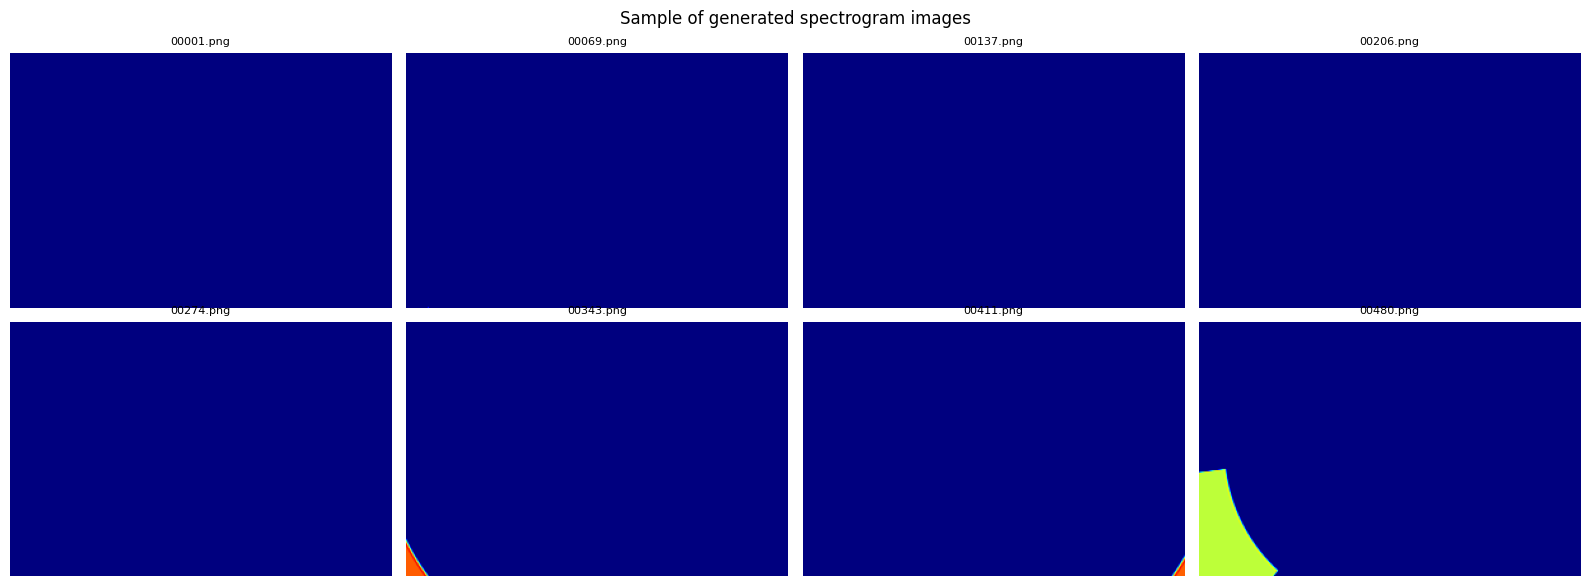

In [14]:
# 随机展示几张生成的频谱图
images_dir = os.path.join(OUTPUT_DIR, 'images')
all_images = sorted(os.listdir(images_dir))

n_show = min(8, len(all_images))
fig, axes = plt.subplots(2, n_show // 2, figsize=(16, 6))
axes = axes.flatten()

show_indices = np.linspace(0, len(all_images) - 1, n_show, dtype=int)
for ax, idx in zip(axes, show_indices):
    img = imageio.imread(os.path.join(images_dir, all_images[idx]))
    ax.imshow(img)
    ax.set_title(all_images[idx], fontsize=8)
    ax.axis('off')

plt.suptitle('Sample of generated spectrogram images', fontsize=12)
plt.tight_layout()
plt.show()